# MLPC 2026 — Challenge: Sound Event Detection
**Team Temporal Frameworks** — Sebastian Pichler, Laurin Siebert

Extending the segment classifiers from Task 4 to full sound event detection (SED) for recordings of arbitrary length, predicting which of the 15 classes are active and when (onset/offset).

Pipeline mirrors the provided challenge baseline, scoring uses the official segment-based macro F1 from `evaluate.py`.

Task 1 (baseline reproduction) is handled by the provided `challenge_baseline/` notebook, this notebook starts at Task 2.

### What this notebook covers

1. Setup
2. Feature & label loading
3. Data splits
4. SED inference & evaluation helpers
5. Training data
6. Task 2 — simple classifier (our XGBoost from Task 4)
7. Hidden-test sumbission

## 1. Setup

In [41]:
import os
import sys
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from xgboost import XGBClassifier
from typing import List, Dict, Tuple, Callable

# evaluate.py is located in the 'provided_baseline' subdirectory
sys.path.insert(0, os.path.join(os.getcwd(), "provided_baseline"))
from evaluate import (
    aggregate_ground_truth_annotations,
    build_segment_frame_from_intervals,
    calculate_f1_score,
)

# copied provided functions from challenge_baseline.ipynb into sed_utils.py for better organization
from sed_utils import (
    build_feature_matrix,
    get_segment_labels,
    load_all_segments,
    run_sed_inference,
    predictions_to_intervals,
    generate_predictions,
    evaluate_split,
)

rng = np.random.default_rng(seed=42)

In [3]:
PATH_TO_DATASET = "../../data/MLPC2026_challenge"

PATH_TRAIN = os.path.join(PATH_TO_DATASET, "train")
PATH_VAL   = os.path.join(PATH_TO_DATASET, "validation")
PATH_TEST  = os.path.join(PATH_TO_DATASET, "test")

# Sanity check — will raise an AssertionError if a path does not exist.
for path in [PATH_TRAIN, PATH_VAL, PATH_TEST]:
    assert os.path.isdir(path), f"Directory not found: {path}"
for path in [
    os.path.join(PATH_TRAIN, "annotations.csv"),
    os.path.join(PATH_TRAIN, "audio_features"),
    os.path.join(PATH_VAL,   "annotations.csv"),
    os.path.join(PATH_VAL,   "audio_features"),
    os.path.join(PATH_TEST,  "audio_features"),
]:
    assert os.path.exists(path), f"Path not found: {path}"

print("Dataset paths OK.")

SEGMENT_LENGTH = 1.0  # each feature vector covers a 1-second window
HOP_SIZE       = 0.5  # segments are extracted with 50% overlap

FEATURE_NAMES = [
    "zcr_mean",        "zcr_std",        "zcr_min",        "zcr_max",
    "melspect_mean",   "melspect_std",   "melspect_min",   "melspect_max",
    "mfcc_mean",       "mfcc_std",       "mfcc_min",       "mfcc_max",
    "mfcc_d_mean",     "mfcc_d_std",     "mfcc_d_min",     "mfcc_d_max",
    "mfcc_d2_mean",    "mfcc_d2_std",    "mfcc_d2_min",    "mfcc_d2_max",
    "flux_mean",       "flux_std",       "flux_min",       "flux_max",
    "flatness_mean",   "flatness_std",   "flatness_min",   "flatness_max",
    "centroid_mean",   "centroid_std",   "centroid_min",   "centroid_max",
    "bandwidth_mean",  "bandwidth_std",  "bandwidth_min",  "bandwidth_max",
    "contrast_mean",   "contrast_std",   "contrast_min",   "contrast_max",
    "rolloff_low_mean",  "rolloff_low_std",  "rolloff_low_min",  "rolloff_low_max",
    "rolloff_high_mean", "rolloff_high_std", "rolloff_high_min", "rolloff_high_max",
    "energy_mean",     "energy_std",     "energy_min",     "energy_max",
    "power_mean",      "power_std",      "power_min",      "power_max",
]

# subset settled on in Task 4 (dropped mel-spectrogram, keep zcr / mfcc(+d, +d2) / spectral contrast / power)
# 420 dims for XGBoost
FEATURE_SELECT = [
    "zcr_mean", "zcr_std", "zcr_min", "zcr_max",
    "mfcc_mean", "mfcc_std", "mfcc_min", "mfcc_max",
    "mfcc_d_mean", "mfcc_d_std", "mfcc_d_min", "mfcc_d_max",
    "mfcc_d2_mean", "mfcc_d2_std", "mfcc_d2_min", "mfcc_d2_max",
    "contrast_mean", "contrast_std", "contrast_min", "contrast_max",
    "power_mean", "power_std", "power_min", "power_max",
]

# The 15 target sound event classes — sorted alphabetically to match the .npz annotation order.
CLASS_NAMES = [
    "bell_ringing",
    "coffee_machine",
    "cutlery_dishes",
    "door_open_close",
    "footsteps",
    "keyboard_typing",
    "keychain",
    "light_switch",
    "microwave",
    "phone_ringing",
    "running_water",
    "toilet_flushing",
    "vacuum_cleaner",
    "wardrobe_drawer_open_close",
    "window_open_close",
]

Dataset paths OK.


## 2. Feature & label loading

Each `.npz` holds per-frame features and an `annotations` array of shape `(T, C, A)` — overlap fraction per frame, class, annotator. We binarise a class as active if any annotator overlapped the frame (`> 0`) and then majority-vote across annotators (same rule as the baseline).

In [4]:
# precompute column indices of the FEATURE_SELECT subset
_sample = dict(np.load(sorted(glob.glob(os.path.join(PATH_TRAIN, "audio_features", "*.npz")))[0],allow_pickle=True))
FEATURE_WIDTH = {n: (_sample[n].shape[1] if _sample[n].ndim > 1 else 1) for n in FEATURE_NAMES}

def feature_columns(feature_names) -> np.ndarray:
    span, c = {}, 0
    for n in FEATURE_NAMES:
        span[n] = (c, c + FEATURE_WIDTH[n]); c += FEATURE_WIDTH[n]
    idx = []
    for n in feature_names:
        idx += list(range(*span[n]))
    return np.array(idx)

SELECT_COLS = feature_columns(FEATURE_SELECT)   # column indices of the 420-dim subset

## 3. Data splits

`train` / `validation` / `test` are predefined. The hidden `test` split has no labels, so — as in the baseline — we split the 999 validation recordings 50/50 into a local validation set (modelselection / tuning) and a non-hidden test set (one-shot final check, not used for tuning).

In [5]:
train_files = sorted(glob.glob(os.path.join(PATH_TRAIN, "audio_features", "*.npz")))
val_files   = sorted(glob.glob(os.path.join(PATH_VAL,   "audio_features", "*.npz")))
test_files  = sorted(glob.glob(os.path.join(PATH_TEST,  "audio_features", "*.npz")))

val_shuffled = rng.permutation(val_files).tolist()
half = len(val_shuffled) // 2
our_val_files  = val_shuffled[:half]   # local validation set
our_test_files = val_shuffled[half:]   # non-hidden local test set

print(f"train:           {len(train_files)}")
print(f"local val:       {len(our_val_files)}")
print(f"non-hidden test: {len(our_test_files)}")
print(f"hidden test:     {len(test_files)}")

# validation-split ground truth, shared by both local evaluations
ann_df = pd.read_csv(os.path.join(PATH_VAL, "annotations.csv"))

train:           3704
local val:       499
non-hidden test: 500
hidden test:     1007


## 4. SED inference & evaluation helpers

Inference per recording: predict every overlapping frame, then keep only the whole-second frames (one prediction per second, matching the 1 s metric resolution) and merge consecutive active seconds per class into onset/offset intervals.

A predict function maps a `(N, 960)` feature matrix to `(N, 15)` binary predictions, so the same inference/eval code drives both the decision-tree baseline and XGBoost.

In [6]:
#PredictFn = Callable[[np.ndarray], np.ndarray]   # (N, 960) -> (N, 15) binary

def show_results(macro_f1, results, title):
    print(f"=== {title} — macro F1: {macro_f1:.4f} ===")
    print(results[["annotation", "precision", "recall", "f1"]].to_string(index=False))

## 5. Training data

Stack all 1 s frames from the training split, treating every frame as an independent example. The XGBoost models in Task 2 train on the `FEATURE_SELECT` subset of these (sliced via `SELECT_COLS`).

In [7]:
# Load training segments from all (or a subset of) training recordings.
#
# MAX_TRAINING_FILES    — None = use all ~3 700 training files.
#                         Set to e.g. 500 for a quick test run.
# MAX_TRAINING_SEGMENTS — After loading, randomly subsample to this many segments.
#                         Keeps training fast even when loading all files.
#                         None = keep all loaded segments (can be slow to train).
#
# Tip: A decision tree does not need hundreds of thousands of examples to converge.
# 50 000 segments drawn from diverse recordings is a good default starting point.
MAX_TRAINING_FILES    = None    # None = use all training files
MAX_TRAINING_SEGMENTS = 100_000  # None = keep all loaded segments

train_files_to_use = train_files
if MAX_TRAINING_FILES is not None:
    train_files_to_use = rng.choice(
        train_files, size=min(MAX_TRAINING_FILES, len(train_files)), replace=False
    ).tolist()

print(f"Loading features from {len(train_files_to_use)} training recordings...")
X_train, Y_train = load_all_segments(train_files_to_use)
print(f"Loaded {X_train.shape[0]} segments with {X_train.shape[1]} features each.")

if MAX_TRAINING_SEGMENTS is not None and X_train.shape[0] > MAX_TRAINING_SEGMENTS:
    idx = rng.choice(X_train.shape[0], size=MAX_TRAINING_SEGMENTS, replace=False)
    X_train = X_train[idx]
    Y_train = Y_train[idx]
    print(f"Subsampled to {X_train.shape[0]} segments for faster training.")

print(f"\nFinal training set: {X_train.shape[0]} segments × {X_train.shape[1]} features, {Y_train.shape[1]} classes.")
print()
print("Class distribution — fraction of segments where class is active:")
for i, cls in enumerate(CLASS_NAMES):
    frac = Y_train[:, i].mean()
    bar  = "#" * int(frac * 40)
    print(f"  {cls:<35} {frac:.3f}  {bar}")

Loading features from 3704 training recordings...
Loaded 170508 segments with 960 features each.
Subsampled to 100000 segments for faster training.

Final training set: 100000 segments × 960 features, 15 classes.

Class distribution — fraction of segments where class is active:
  bell_ringing                        0.016  
  coffee_machine                      0.038  #
  cutlery_dishes                      0.080  ###
  door_open_close                     0.056  ##
  footsteps                           0.146  #####
  keyboard_typing                     0.103  ####
  keychain                            0.058  ##
  light_switch                        0.016  
  microwave                           0.076  ###
  phone_ringing                       0.075  ##
  running_water                       0.136  #####
  toilet_flushing                     0.034  #
  vacuum_cleaner                      0.066  ##
  wardrobe_drawer_open_close          0.031  #
  window_open_close                   0.020  


## 6. Task 2 — Simple classifier: XGBoost from Task 4

**2(a)** Our best classical model from Task 4 was a per-class binary XGBoost (binary relevance — one model per class). Gradient-boosted trees were robust on the tabular features with little preprocessing, key modification was a per-class `scale_pos_weight = neg/pos` to counter the heavy frame-level class imbalance (slightly improved rare classes like `light_switch`). 

Core hyperparameters: `n_estimators=100`, `learning_rate=0.1`, `max_depth=6`, `min_child_weight=3`, `subsample=0.8`, `tree_method="hist"`. Features: Task 4 subset (`FEATURE_SELECT`, 420 dims).

> Our overall best in Task 4 was actually the focal-loss MLP, but per task instruction we use our best classical model here.

In [56]:
def select_features(X):
    return X[:, SELECT_COLS]

def train_xgb_per_class(X, Y, **params):
    """Binary-relevance XGBoost: one model per class, per-class positive weighting."""
    Xs = select_features(X)
    models = {}
    for ci, cls in enumerate(CLASS_NAMES):
        y = Y[:, ci]
        pos = int(np.sum(y == 1))
        neg = int(np.sum(y == 0))
        models[cls] = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            scale_pos_weight=(neg / pos if pos else 1.0),
            n_jobs=-1,
            random_state=42,
            **params,
        ).fit(Xs, y)
    return models

def xgb_predict_fn(models):
    """Wrap per-class models into a (N, 960) -> (N, 15) predictor function."""
    def predict(X):
        Xs = select_features(X)
        return np.column_stack([models[c].predict(Xs) for c in CLASS_NAMES])
    return predict

# paramters from Task 4 (except increased n_estimators 100 -> 300 after grid search in 2b)
XGB_PARAMS = dict(n_estimators=300, learning_rate=0.1, max_depth=6, min_child_weight=3, subsample=0.8)

print("training per-class XGBoost...")
t = time.time()
xgb_models = train_xgb_per_class(X_train, Y_train, **XGB_PARAMS)
print(f"trained {len(xgb_models)} models in {time.time() - t:.1f}s")

xgb_predict = xgb_predict_fn(xgb_models)

pred_val_xgb  = generate_predictions(our_val_files,  xgb_predict)
pred_test_xgb = generate_predictions(our_test_files, xgb_predict)

f1_val_xgb,  res_val_xgb  = evaluate_split(pred_val_xgb,  our_val_files,  ann_df)
f1_test_xgb, res_test_xgb = evaluate_split(pred_test_xgb, our_test_files, ann_df)

show_results(f1_val_xgb,  res_val_xgb,  "XGBoost / local val")
print()
show_results(f1_test_xgb, res_test_xgb, "XGBoost / non-hidden test")

training per-class XGBoost...
trained 15 models in 936.0s
=== XGBoost / local val — macro F1: 0.5490 ===
                annotation  precision   recall       f1
              bell_ringing   0.538462 0.285714 0.373333
            coffee_machine   0.628770 0.520154 0.569328
            cutlery_dishes   0.587025 0.622483 0.604235
           door_open_close   0.340630 0.455504 0.389780
                 footsteps   0.544485 0.629981 0.584121
           keyboard_typing   0.725806 0.659824 0.691244
                  keychain   0.569028 0.574545 0.571773
              light_switch   0.763636 0.392523 0.518519
                 microwave   0.621542 0.599619 0.610383
             phone_ringing   0.705036 0.600000 0.648291
             running_water   0.832746 0.770270 0.800290
           toilet_flushing   0.594272 0.600000 0.597122
            vacuum_cleaner   0.792126 0.674263 0.728458
wardrobe_drawer_open_close   0.326180 0.271429 0.296296
         window_open_close   0.275424 0.231317 0.251451

**2(b)** Effect of two important hyperparameters — `n_estimators` and `max_depth` — on the segment-based macro F1. We tune on the local validation split only.

In [9]:
sweep_estimators = [100, 200, 300]
sweep_depth = [4, 6, 8]

#sweep = []
#for nr_est in sweep_estimators:
#    for max_dep in sweep_depth:
#        params = {**XGB_PARAMS, "n_estimators": nr_est, "max_depth": max_dep}
#        models = train_xgb_per_class(X_train, Y_train, **params)
#        pdf = generate_predictions(our_val_files, xgb_predict_fn(models))
#        f1, _ = evaluate_split(pdf, our_val_files, ann_df)
#        sweep.append({"n_estimators": nr_est, "max_depth": max_dep, "macro_f1": f1})
#        print(f"  n_estimators={nr_est:<4} max_depth={max_dep}  ->  macro_f1={f1:.4f}")
#
#sweep_df = pd.DataFrame(sweep)
#pivot = sweep_df.pivot(index="max_depth", columns="n_estimators", values="macro_f1")
#print("\nmacro F1 (rows = max_depth, cols = n_estimators):")
#print(pivot.round(4).to_string())

# results from the sweep (commented out to avoid long runtime on every execution)
print("""\
  n_estimators=100  max_depth=4  ->  macro_f1=0.4401
  n_estimators=100  max_depth=6  ->  macro_f1=0.5045
  n_estimators=100  max_depth=8  ->  macro_f1=0.5385
  n_estimators=200  max_depth=4  ->  macro_f1=0.4813
  n_estimators=200  max_depth=6  ->  macro_f1=0.5434
  n_estimators=200  max_depth=8  ->  macro_f1=0.5367
  n_estimators=300  max_depth=4  ->  macro_f1=0.5070
  n_estimators=300  max_depth=6  ->  macro_f1=0.5527
  n_estimators=300  max_depth=8  ->  macro_f1=0.5235

macro F1 (rows = max_depth, cols = n_estimators):
n_estimators     100     200     300
max_depth                           
4             0.4401  0.4813  0.5070
6             0.5045  0.5434  0.5527
8             0.5385  0.5367  0.5235""")

  n_estimators=100  max_depth=4  ->  macro_f1=0.4401
  n_estimators=100  max_depth=6  ->  macro_f1=0.5045
  n_estimators=100  max_depth=8  ->  macro_f1=0.5385
  n_estimators=200  max_depth=4  ->  macro_f1=0.4813
  n_estimators=200  max_depth=6  ->  macro_f1=0.5434
  n_estimators=200  max_depth=8  ->  macro_f1=0.5367
  n_estimators=300  max_depth=4  ->  macro_f1=0.5070
  n_estimators=300  max_depth=6  ->  macro_f1=0.5527
  n_estimators=300  max_depth=8  ->  macro_f1=0.5235

macro F1 (rows = max_depth, cols = n_estimators):
n_estimators     100     200     300
max_depth                           
4             0.4401  0.4813  0.5070
6             0.5045  0.5434  0.5527
8             0.5385  0.5367  0.5235


**2(c)** Final comparison of XGBoost vs. the decision-tree baseline on the non-hidden testset.

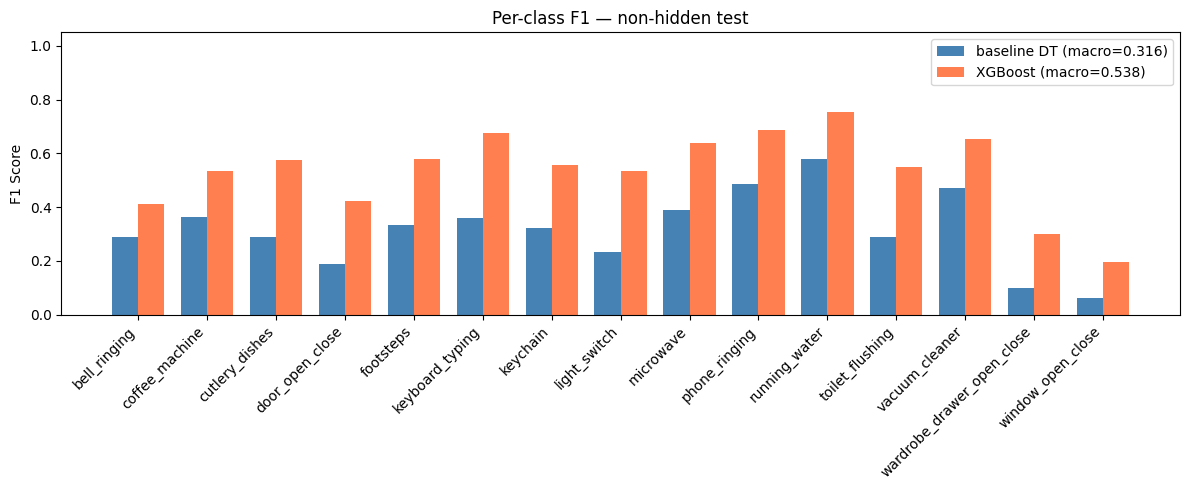

F1 change (XGBoost - baseline), non-hidden test:
annotation
bell_ringing                  0.1233
window_open_close             0.1362
coffee_machine                0.1706
running_water                 0.1774
vacuum_cleaner                0.1839
wardrobe_drawer_open_close    0.2008
phone_ringing                 0.2018
keychain                      0.2322
door_open_close               0.2356
footsteps                     0.2464
microwave                     0.2489
toilet_flushing               0.2587
cutlery_dishes                0.2860
light_switch                  0.3015
keyboard_typing               0.3181


In [10]:
# per-class F1 of the provided decision-tree baseline on the non-hidden test split (results from challenge_baseline.ipynb)
baseline_test_f1 = {
    "bell_ringing": 0.288235,
    "coffee_machine": 0.362007,
    "cutlery_dishes": 0.287406,
    "door_open_close": 0.188335,
    "footsteps": 0.332757,
    "keyboard_typing": 0.359081,
    "keychain": 0.322840,
    "light_switch": 0.233663,
    "microwave": 0.389610,
    "phone_ringing": 0.484848,
    "running_water": 0.577178,
    "toilet_flushing": 0.290353,
    "vacuum_cleaner": 0.469742,
    "wardrobe_drawer_open_close": 0.097616,
    "window_open_close": 0.061093,
}

# Visualize per-class F1 scores (XGBoost vs. baseline) on the non-hidden test split - same plot as in challenge_baseline.ipynb
xgb_f1 = res_test_xgb.set_index("annotation")["f1"].reindex(CLASS_NAMES)
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(CLASS_NAMES))
width = 0.38

base_f1 = pd.Series(baseline_test_f1).reindex(CLASS_NAMES)
ax.bar(x - width/2, base_f1.values, width, label=f"baseline DT (macro={base_f1.mean():.3f})", color="steelblue")
ax.bar(x + width/2, xgb_f1.values,  width, label=f"XGBoost (macro={f1_test_xgb:.3f})", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1 — non-hidden test")
ax.legend()
plt.tight_layout()
plt.savefig("XGBoost_vs_baseline_300_estimators.png", dpi=300)
plt.show()

# print differences in F1
delta = (xgb_f1 - base_f1).sort_values()
print("F1 change (XGBoost - baseline), non-hidden test:")
print(delta.round(4).to_string())

**2(d)** Qualitative error analysis: log-mel spectrogram with ground-truth vs. predicted labels over time for a few test recordings. Discussion of correct detections, misses, false positives, and timing errors.

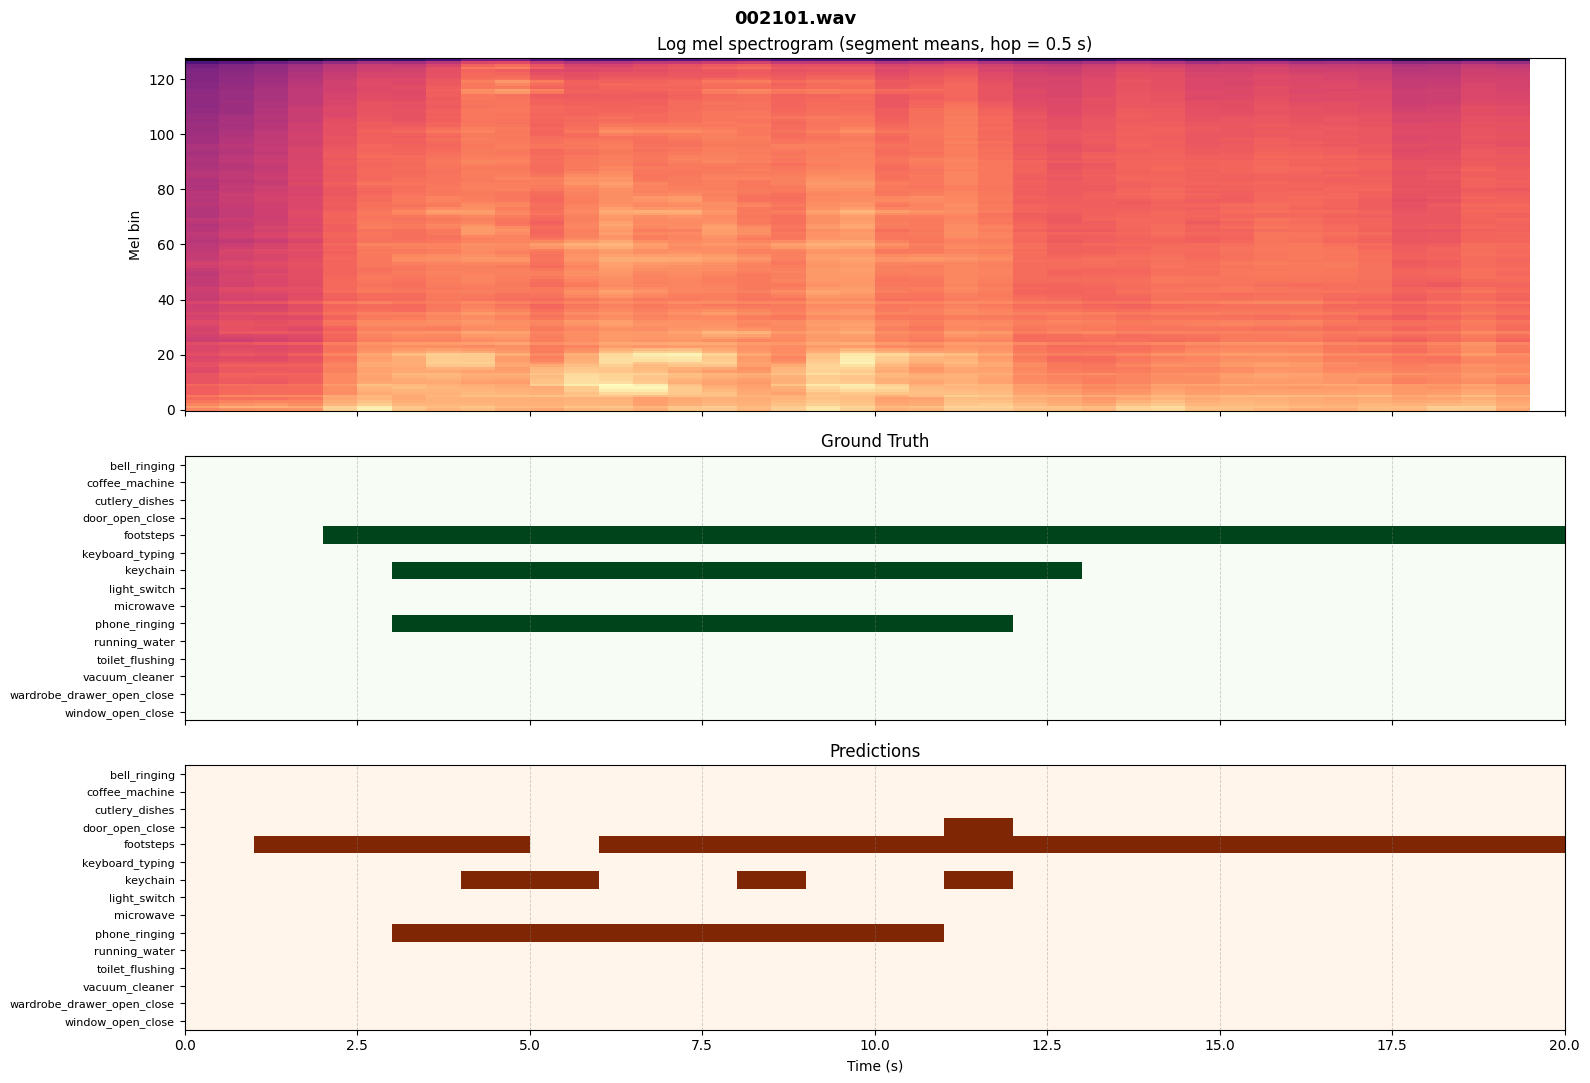

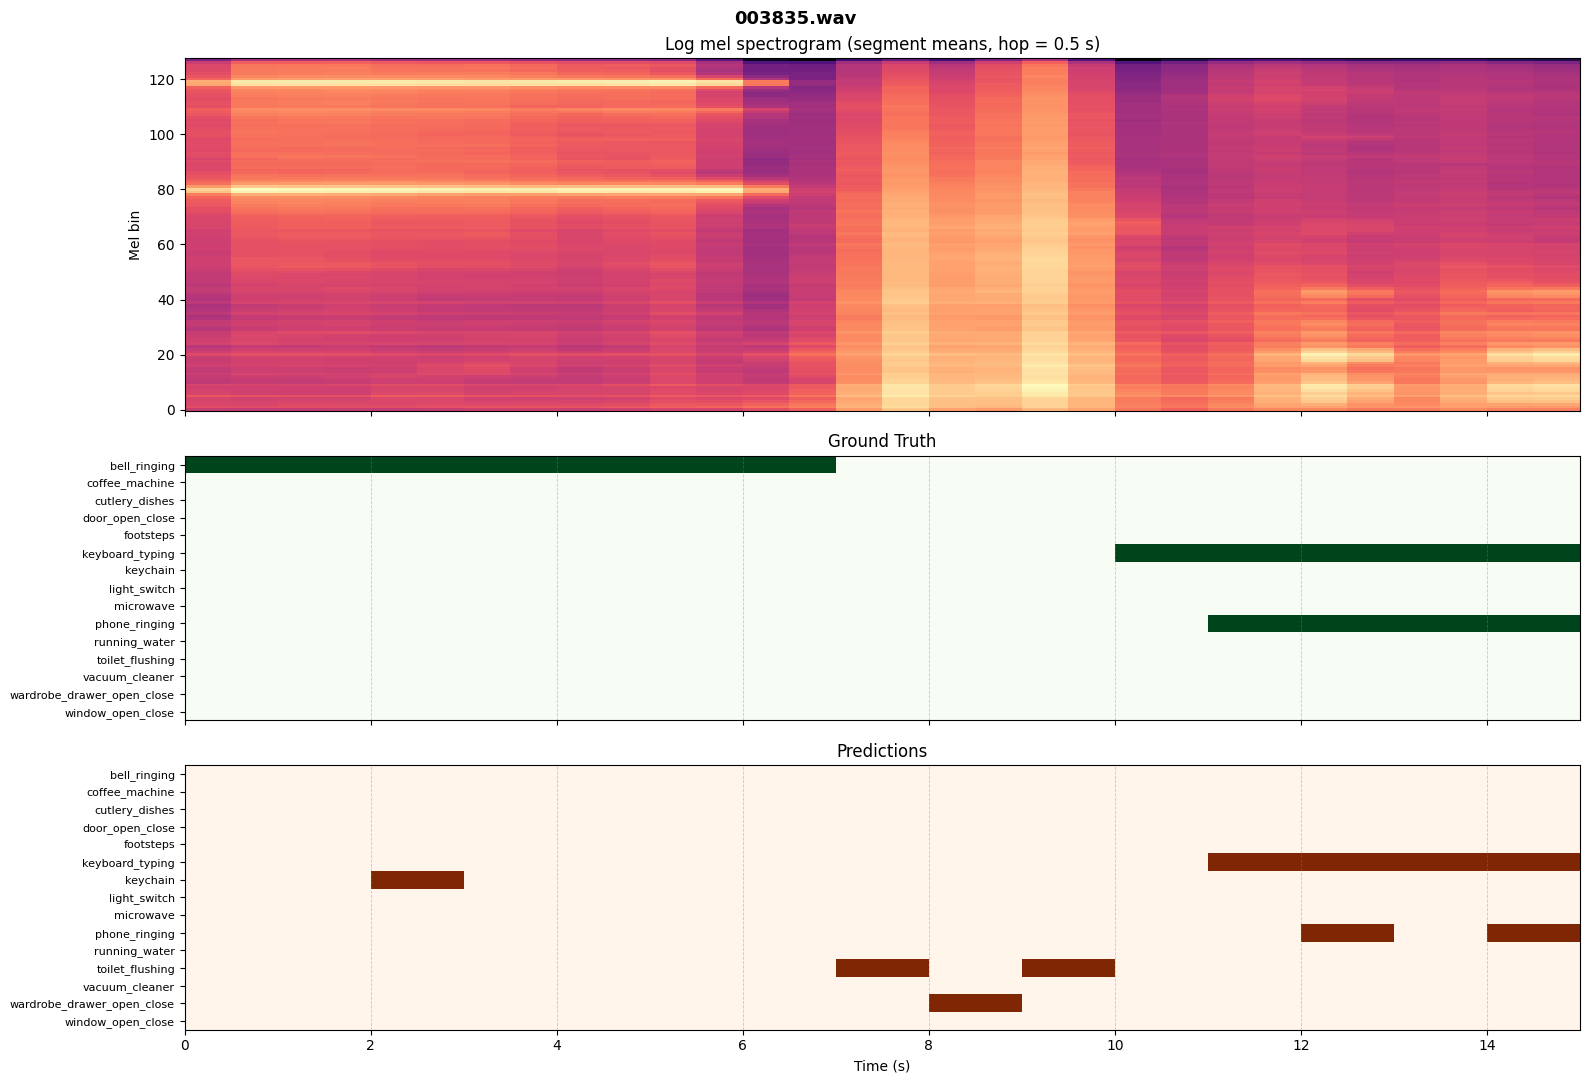

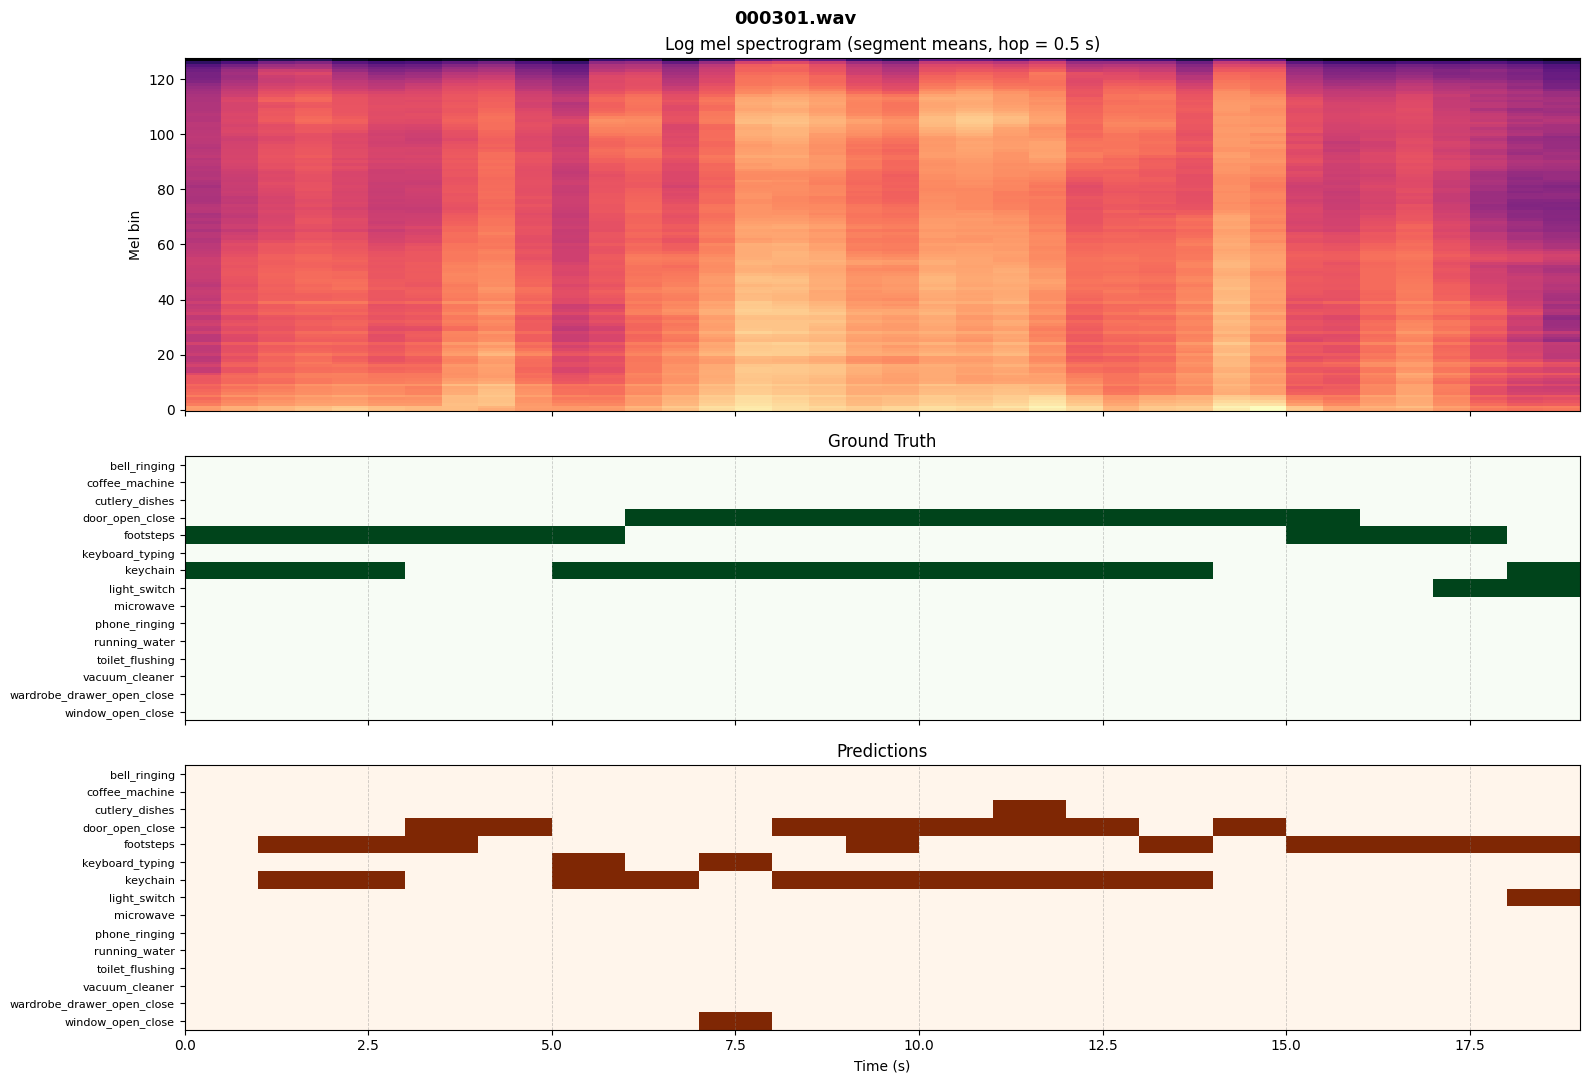

In [11]:
# reuse the SED inference and visualization code from challenge_baseline.ipynb to plot some examples with predictions vs. ground truth
def plot_sed_example(filepath, predict_fn):

    recording_features = dict(np.load(filepath, allow_pickle=True))
    start_times = recording_features["start_time"]                      # [0.0, 0.5, 1.0, ...]
    
    # whole-second mask — same filter used in run_sed_inference / challenge_baseline.ipynb
    whole_second_mask = np.isclose(start_times % 1.0, 0.0)

    # run inference to get predictions and time axis for the predicted segments
    preds, times, fname = run_sed_inference(filepath, predict_fn)

    # ground-truth labels at whole-second resolution (majority-vote across annotators)
    gt_all  = get_segment_labels(recording_features)    # (N_all_segments, C)
    gt_whole = gt_all[whole_second_mask]                # (N_ws, C)

    # Log-mel spectrogram: use ALL segments (hop=0.5 s) for twice the time resolution
    mel_log = np.log1p(recording_features["melspect_mean"].T) # (n_mels, N_all)

    C = len(CLASS_NAMES)

    # pcolormesh edge arrays
    t_edges_all = np.append(start_times, start_times[-1] + HOP_SIZE)
    t_edges_ws  = np.append(times, float(times[-1]) + SEGMENT_LENGTH)
    mel_edges   = np.arange(mel_log.shape[0] + 1) - 0.5
    cls_edges   = np.arange(C + 1) - 0.5

    fig, ax = plt.subplots(3, 1, figsize=(16, 11),
                            gridspec_kw={"height_ratios": [2, 1.5, 1.5]},
                            sharex=True)
    fig.suptitle(fname, fontsize=13, fontweight="bold")

    # --- 1. Log-mel spectrogram ---
    ax[0].pcolormesh(t_edges_all, mel_edges, mel_log, cmap="magma", shading="flat")
    ax[0].set_ylabel("Mel bin")
    ax[0].set_title("Log mel spectrogram (segment means, hop = 0.5 s)")
    # color bar removed to align with spectrum with graphs below!

    # --- 2. Ground truth ---
    ax[1].pcolormesh(t_edges_ws, cls_edges, gt_whole.T, cmap="Greens", vmin=0, vmax=1, shading="flat")
    ax[1].set_yticks(range(C))
    ax[1].set_yticklabels(CLASS_NAMES, fontsize=8)
    ax[1].invert_yaxis()
    ax[1].set_title("Ground Truth")
    ax[1].grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4, color="gray")

    # --- 3. Predictions ---
    ax[2].pcolormesh(t_edges_ws, cls_edges, preds.T, cmap="Oranges", vmin=0, vmax=1, shading="flat")
    ax[2].set_yticks(range(C))
    ax[2].set_yticklabels(CLASS_NAMES, fontsize=8)
    ax[2].invert_yaxis()
    ax[2].set_title("Predictions")
    ax[2].grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4, color="gray")
    ax[2].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()


for fp in our_test_files[:3]:
    plot_sed_example(fp, xgb_predict)

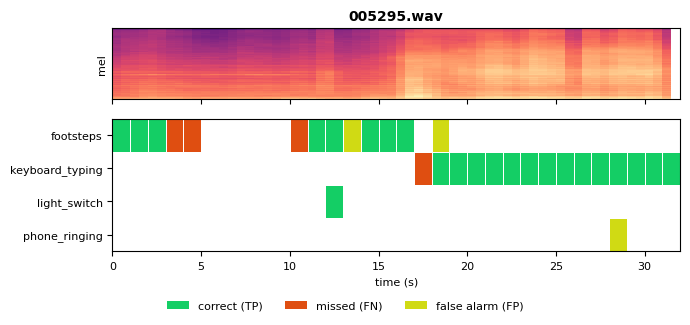

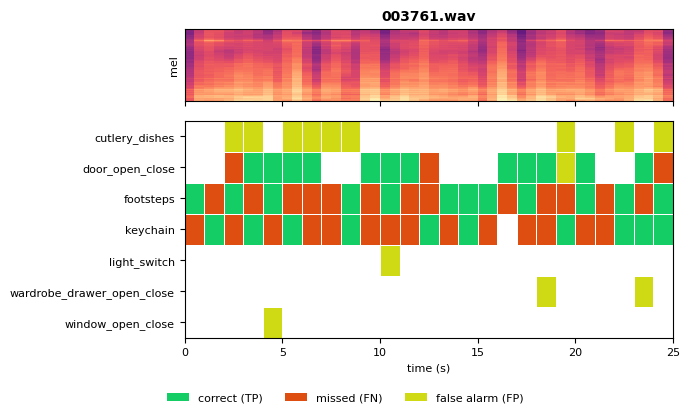

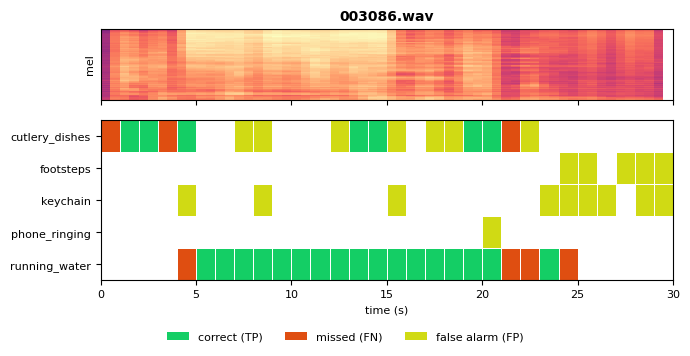

In [12]:
# ----- GENERATED BY MONSIEUR CLAUDE BECAUSE MY PATIENCE RAN OUT to come up with something more compact than the baseline implementation -----

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# status code per (class, second): 0 none | 1 TP | 2 miss (FN) | 3 false alarm (FP)
_CMAP = ListedColormap(["#ffffff", "#14ce65", "#df4e11", "#d0da14"])
_NORM = BoundaryNorm([0, 1, 2, 3, 4], _CMAP.N)
_LEGEND = [Patch(facecolor="#14ce65", label="correct (TP)"),
           Patch(facecolor="#df4e11", label="missed (FN)"),
           Patch(facecolor="#d0da14", label="false alarm (FP)")]


def plot_sed_compact(filepath, predict_fn, show_spec=True):
    data = dict(np.load(filepath, allow_pickle=True))
    start_times = data["start_time"]
    ws = np.isclose(start_times % 1.0, 0.0)

    preds, times, fname = run_sed_inference(filepath, predict_fn)   # (T, 15)
    gt = get_segment_labels(data)[ws]                               # (T, 15)

    active = np.where(gt.any(0) | preds.any(0))[0]                  # only used classes
    if len(active) == 0:
        return
    g, p = gt[:, active].T, preds[:, active].T                     # (A, T)

    status = np.zeros_like(g, dtype=int)
    status[(g == 1) & (p == 1)] = 1     # TP
    status[(g == 1) & (p == 0)] = 2     # miss
    status[(g == 0) & (p == 1)] = 3     # false alarm

    t_edges = np.append(times, times[-1] + SEGMENT_LENGTH)
    y_edges = np.arange(len(active) + 1) - 0.5
    h = 0.30 * len(active) + 1.1

    if show_spec:
        fig, (axs, ax) = plt.subplots(
            2, 1, figsize=(7, h + 0.9), sharex=True,
            gridspec_kw={"height_ratios": [0.8, 0.30 * len(active) + 0.3]})
        mel = np.log1p(data["melspect_mean"].T)
        axs.pcolormesh(np.append(start_times, start_times[-1] + HOP_SIZE),
                       np.arange(mel.shape[0] + 1) - 0.5, mel,
                       cmap="magma", shading="flat", rasterized=True)
        axs.set_yticks([]); axs.set_ylabel("mel", fontsize=8)
        axs.set_title(fname, fontsize=10, fontweight="bold")
    else:
        fig, ax = plt.subplots(figsize=(7, h))
        ax.set_title(fname, fontsize=10, fontweight="bold")

    ax.pcolormesh(t_edges, y_edges, status, cmap=_CMAP, norm=_NORM,
                  shading="flat", edgecolors="white", linewidth=0.5)
    ax.set_yticks(range(len(active)))
    ax.set_yticklabels([CLASS_NAMES[c] for c in active], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("time (s)", fontsize=8)
    ax.tick_params(labelsize=8)
    fig.legend(handles=_LEGEND, ncol=3, fontsize=8, frameon=False,
               loc="lower center", bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig


# the files to plot
SELECTED = ["005295", "003761", "003086"]

# map each selection to its full .npz path in our_test_files
by_stem = {os.path.basename(fp).replace(".npz", ""): fp for fp in our_test_files}

selected_files = []
for name in SELECTED:
    stem = os.path.basename(name).replace(".wav", "").replace(".npz", "")
    if stem in by_stem:
        selected_files.append(by_stem[stem])
    else:
        print(f"{name} not in our_test_files — skipping")

# show and save
for fp in selected_files:
    fig = plot_sed_compact(fp, xgb_predict, show_spec=True)
    fig.savefig(f"sed_{os.path.basename(fp).replace('.npz','')}.png", bbox_inches="tight")
    plt.show()

## X. Hidden-test submission

Output test - generate predictions for the hidden test split with XGBoost model and write the submission CSV (`filename, annotation, onset, offset`). Retraining on `train + validation` for submission later.

In [13]:
print(f"Generating predictions for {len(test_files)} hidden test recordings...")
pred_hidden = generate_predictions(test_files, xgb_predict)

OUT = "predictions_hidden_test_XGBOOST.csv"
pred_hidden.to_csv(OUT, index=False)
print(f"wrote {len(pred_hidden)} rows to {OUT}")
print(f"classes predicted: {sorted(pred_hidden['annotation'].unique())}")
pred_hidden.head()

Generating predictions for 1007 hidden test recordings...
wrote 10684 rows to predictions_hidden_test_XGBOOST.csv
classes predicted: ['bell_ringing', 'coffee_machine', 'cutlery_dishes', 'door_open_close', 'footsteps', 'keyboard_typing', 'keychain', 'light_switch', 'microwave', 'phone_ringing', 'running_water', 'toilet_flushing', 'vacuum_cleaner', 'wardrobe_drawer_open_close', 'window_open_close']


,filename,annotation,onset,offset
0,000020.wav,cutlery_dishes,3.0,4.0
1,000020.wav,cutlery_dishes,22.0,23.0
2,000020.wav,cutlery_dishes,24.0,25.0
3,000020.wav,cutlery_dishes,26.0,27.0
4,000020.wav,door_open_close,2.0,3.0


## 3 Post-Processing and Temporal Refinement
### 3a Median Filtering

In [75]:
def run_sed_inference_proba(
    filepath: str,
    classifier
) -> Tuple[np.ndarray, np.ndarray, str]:
    data = dict(np.load(filepath, allow_pickle=True))
    start_times_all = data["start_time"]

    # Build feature matrix for ALL segments (both whole-second and half-second)
    X_all = build_feature_matrix(data)     # shape: (N_all_segments, D_features)

    # Check if it's the raw scikit-learn MultiOutputClassifier
    if hasattr(classifier, "predict_proba") and not callable(classifier):
        # predict_proba returns a list of shapes [(N, 2), (N, 2), ...]
        prob_list = classifier.predict_proba(X_all)
        # Extract the probability of the positive class (column 1) for each class
        pred_all = np.column_stack([prob[:, 1] for prob in prob_list])
    else:
        # It's our custom wrapper function (or another callable)
        pred_all = classifier(X_all) # Expecting shape: (N_all_segments, N_classes)

    # Identify segments that start at a whole-second timestamp (0.0, 1.0, 2.0, ...)
    whole_second_mask = np.isclose(start_times_all % 1.0, 0.0)
    # The half-second segments (0.5, 1.5, ...) are dropped here.
    # Future improvement: use them to smooth predictions or refine temporal boundaries.

    predictions = pred_all[whole_second_mask]
    start_times = start_times_all[whole_second_mask]

    filename = os.path.basename(filepath).replace(".npz", ".wav")
    return predictions, start_times, filename

def xgb_predict_fn_proba(models):
    """Wrap per-class models into a (N, 960) -> (N, 15) predictor function."""
    def predict(X):
        Xs = select_features(X)
        return np.column_stack([models[c].predict_proba(Xs)[:, 1] for c in CLASS_NAMES])
    return predict

xgb_predict_median = xgb_predict_fn_proba(xgb_models)
median_preds_val = []
for file in our_val_files:
    data = np.load(file)
    preds, times, fname = run_sed_inference_proba(file, xgb_predict_median)
    preds = preds.astype(float)

    preds_med_filtering = medfilt(volume=preds, kernel_size=[3, 1])

    preds_med_filtering = (preds_med_filtering >= 0.3).astype(int)

    median_preds_val.extend(predictions_to_intervals(preds_med_filtering, times, fname))

f1_val_median,  res_val_median  = evaluate_split(pd.DataFrame(median_preds_val),  our_val_files,  ann_df)
show_results(f1_val_xgb,  res_val_xgb,  "XGBoost / local val")
print()
show_results(f1_val_median,  res_val_median,  "XGBoost median filtering / local val")
print()

=== XGBoost / local val — macro F1: 0.5490 ===
                annotation  precision   recall       f1
              bell_ringing   0.538462 0.285714 0.373333
            coffee_machine   0.628770 0.520154 0.569328
            cutlery_dishes   0.587025 0.622483 0.604235
           door_open_close   0.340630 0.455504 0.389780
                 footsteps   0.544485 0.629981 0.584121
           keyboard_typing   0.725806 0.659824 0.691244
                  keychain   0.569028 0.574545 0.571773
              light_switch   0.763636 0.392523 0.518519
                 microwave   0.621542 0.599619 0.610383
             phone_ringing   0.705036 0.600000 0.648291
             running_water   0.832746 0.770270 0.800290
           toilet_flushing   0.594272 0.600000 0.597122
            vacuum_cleaner   0.792126 0.674263 0.728458
wardrobe_drawer_open_close   0.326180 0.271429 0.296296
         window_open_close   0.275424 0.231317 0.251451

=== XGBoost median filtering / local val — macro F1: 0.5

In [78]:
median_preds_test = []
for file in our_test_files:
    data = np.load(file)
    preds, times, fname = run_sed_inference_proba(file, xgb_predict_median)
    preds = preds.astype(float)

    preds_med_filtering = medfilt(volume=preds, kernel_size=[3, 1])

    preds_med_filtering = (preds_med_filtering >= 0.3).astype(int)

    median_preds_test.extend(predictions_to_intervals(preds_med_filtering, times, fname))

f1_test_median,  res_test_median  = evaluate_split(pd.DataFrame(median_preds_test),  our_test_files,  ann_df)
show_results(f1_test_xgb,  res_test_xgb,  "XGBoost / local test")
print()
show_results(f1_test_median,  res_test_median,  "XGBoost median filtering / local test")
print()

=== XGBoost / local test — macro F1: 0.5378 ===
                annotation  precision   recall       f1
              bell_ringing   0.744186 0.284444 0.411576
            coffee_machine   0.705069 0.427972 0.532637
            cutlery_dishes   0.519182 0.640379 0.573446
           door_open_close   0.380553 0.478398 0.423903
                 footsteps   0.553571 0.607314 0.579199
           keyboard_typing   0.679321 0.674960 0.677134
                  keychain   0.583548 0.529138 0.555012
              light_switch   0.682635 0.440154 0.535211
                 microwave   0.683871 0.598870 0.638554
             phone_ringing   0.704167 0.669970 0.686643
             running_water   0.777023 0.733366 0.754564
           toilet_flushing   0.538889 0.559615 0.549057
            vacuum_cleaner   0.690815 0.620209 0.653611
wardrobe_drawer_open_close   0.305732 0.291498 0.298446
         window_open_close   0.221739 0.177700 0.197292

=== XGBoost median filtering / local test — macro F1: 0

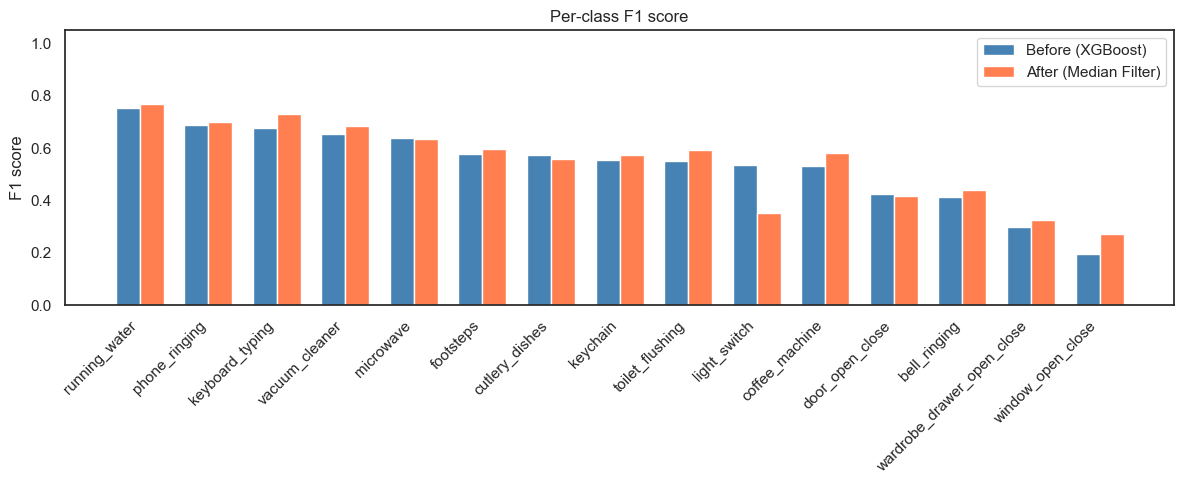

In [95]:
df_before = res_test_xgb.copy()
df_after = res_test_median.copy()

order = df_before.sort_values("f1", ascending=False)["annotation"].tolist()

df_before = df_before.set_index("annotation").loc[order]
df_after = df_after.set_index("annotation").loc[order]

x = np.arange(len(order))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(x - width/2, df_before["f1"], width, label="Before (XGBoost)", color="steelblue")
plt.bar(x + width/2, df_after["f1"], width, label="After (Median Filter)", color="coral")

plt.xticks(x, order, rotation=45, ha="right")

plt.ylabel("F1 score")
plt.title("Per-class F1 score")

plt.ylim(0, 1.05)

ax = plt.gca()

plt.legend()
plt.tight_layout()
plt.savefig("median_filtering", dpi=300)
plt.show()